In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [2]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root='../data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

In [3]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [4]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [5]:
generator = Generator()
discriminator = Discriminator()

In [6]:
criterion = nn.BCELoss()

lr = 0.0002

g_optimizer = optim.Adam(generator.parameters(), lr=lr)
d_optimizer = optim.Adam(discriminator.parameters(), lr=lr)

In [7]:
epochs = 10

for epoch in range(epochs):
    for images, _ in tqdm(train_loader):

        # Flatten images
        real_images = images.view(-1, 784)
        batch_size = real_images.size(0)

        # Labels
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        # -------------------------
        # Train Discriminator
        # -------------------------
        noise = torch.randn(batch_size, 100)
        fake_images = generator(noise)

        real_loss = criterion(discriminator(real_images), real_labels)
        fake_loss = criterion(discriminator(fake_images.detach()), fake_labels)

        d_loss = real_loss + fake_loss

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # -------------------------
        # Train Generator
        # -------------------------
        noise = torch.randn(batch_size, 100)
        fake_images = generator(noise)

        g_loss = criterion(discriminator(fake_images), real_labels)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

100%|█████████████████████████████████████████████████████████████████████████████████| 938/938 [00:11<00:00, 81.65it/s]


Epoch [1/10] | D Loss: 0.1316 | G Loss: 3.7151


100%|█████████████████████████████████████████████████████████████████████████████████| 938/938 [00:14<00:00, 65.24it/s]


Epoch [2/10] | D Loss: 0.2535 | G Loss: 4.9376


100%|█████████████████████████████████████████████████████████████████████████████████| 938/938 [00:16<00:00, 57.61it/s]


...

Epoch [8/10] | D Loss: 0.0426 | G Loss: 5.3490


100%|█████████████████████████████████████████████████████████████████████████████████| 938/938 [00:17<00:00, 54.89it/s]


Epoch [9/10] | D Loss: 0.1049 | G Loss: 5.7298


100%|█████████████████████████████████████████████████████████████████████████████████| 938/938 [00:19<00:00, 48.74it/s]

Epoch [10/10] | D Loss: 0.0188 | G Loss: 5.6329


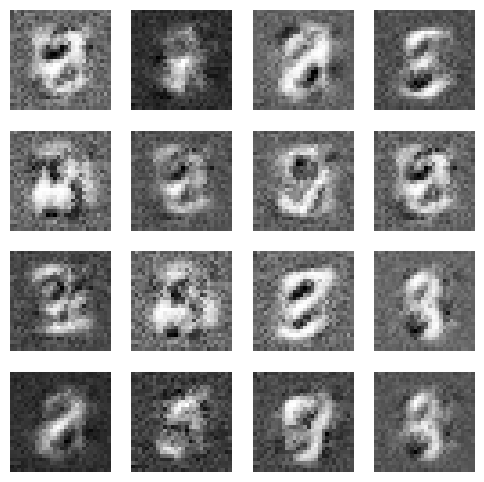

In [8]:
generator.eval()

noise = torch.randn(16, 100)
generated_images = generator(noise).detach().numpy()

plt.figure(figsize=(6,6))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(generated_images[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

In [9]:
torch.save(generator.state_dict(), "../models/gan/generator.pth")
torch.save(discriminator.state_dict(), "../models/gan/discriminator.pth")

print("GAN models saved!")

GAN models saved!
